# Assignment 3 - Jonas Gstöttenmayr

**ATTNENTION:** For the Answers to the questions they are written in the same markdown box as the task descirption

In [1]:
import numpy as np

In [2]:
from sklearn.datasets import fetch_20newsgroups

cats = ['sci.space', 'comp.graphics', 'rec.sport.hockey', 'alt.atheism']
data = fetch_20newsgroups(subset='train', categories=cats, remove=('headers', 'footers', 'quotes'))
X_text, y, target_names = np.array(data.data), data.target, data.target_names

In [3]:
rng = np.random.default_rng(42)

**Exercise 1 Bag of Words & TF-IDF**

In the first exercise, compare the Bag of Words and TF-IDF representations for the 20 news-
groups text dataset by taking a look at the similarities between the 5 news categories.

**Tasks**

* Fit CountVectorizer (Bag of Words) and TfidfVectorizer (TF-IDF). Make sure to remove
the stopwords.
* Top terms per class based on TF-IDF: For each category, compute the top-10 terms by
average TF-IDF over the whole corpus.
* Similarity: Pick a random message for each category. For those messages, compute the
cosine similarity of the TF-IDF and BoW representations. Compare which representation
separates categories better.
* Discuss in exercise: When does TF-IDF outperform BoW?

**Answer**

TF-IDF outperforms BOW when looking for relevant words, as can be seen when computing the highest averge per category, with the 10 words really showing what each category is about.

With BOW we also have usually higher similarity scores when comparing different categories, as can be seen by the random comparison above where we needed to go through many larger BOW similarites before TF-IDf actually goes above my threashold.
As such it outperforms it too when differentiating texts according to topics

TF-IDF also generally outperforms BOW through being a natural filter/shield against common words (even after filtering for stopwords) allowing more topic unique words to shine through thus conveying more sementic meaning about the text.

With BOW we simply the get the total word count, which is quickly distorted through often repeated words while TF-IDF looks for document frequent but uniquish to said document words, leading to more sementic meaning for each document being convayed/safed, but also to a requirement of multiple documents to be effective/work at all.

In [4]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from numpy import ndarray

In [5]:
# set up, fit and tranform with tokenizers
cv = CountVectorizer(stop_words="english")
tv = TfidfVectorizer(stop_words="english")

bow_rep = cv.fit_transform(X_text)
tfidf_rep = tv.fit_transform(X_text)

cv.get_feature_names_out()

array(['00', '000', '0000', ..., 'zwarte', 'zyxel', 'zzzzzz'],
      shape=(28209,), dtype=object)

In [6]:
print(X_text[0][4:80]) # checking if it is unique
print("Amount of at   in vocab: ", np.array(cv.get_feature_names_out() == "at").sum())
print("Amount of fact in vocab: ", np.array(cv.get_feature_names_out() == "fact").sum())

In fact, you can all direct your ire at the proper target by ingoring NASA 

Amount of at   in vocab:  0
Amount of fact in vocab:  1


In [7]:
mask  = (y == 2)
tfidf_rep[mask].shape#.mean(axis=0).A1

(600, 28209)

In [8]:
feature_names = tv.get_feature_names_out()
for cat_id, cat in enumerate(target_names):
    mask: ndarray = (y == cat_id)
    avg_tfidf: ndarray = tfidf_rep[mask].mean(axis=0).A1 # mean tfidf score mean, axis=0 is the vocab of 28209 tokens, A1 the first column (mean values)
    top_10 = feature_names[avg_tfidf.argsort()[-10:][::-1]]
    print(f"Top terms for {cat}: {top_10}")

Top terms for alt.atheism: ['god' 'people' 'don' 'think' 'just' 'religion' 'say' 'atheism' 'does'
 'islam']
Top terms for comp.graphics: ['graphics' 'thanks' 'image' 'files' 'file' 'know' 'program' 'does'
 'looking' 'windows']
Top terms for rec.sport.hockey: ['game' 'team' 'hockey' 'games' 'play' 'season' 'players' 'nhl' 'year'
 'think']
Top terms for sci.space: ['space' 'nasa' 'like' 'launch' 'moon' 'just' 'orbit' 'earth' 'shuttle'
 'think']


In [9]:
first_idx, second_idx = 0, 3
c1, c2 = target_names[first_idx], target_names[second_idx]
sim = 0
threashold = 0.05

while sim <threashold:
    first_text = X_text[y==first_idx]
    first_rand_idx = rng.integers(0, first_text.shape[0]-1)

    second_text = X_text[y==second_idx]
    second_rand_idx = rng.integers(0, second_text.shape[0]-1)

    for name, matrix in zip(["BoW", "TF-IDF"], [bow_rep, tfidf_rep]):
        first = matrix[y==first_idx]

        second = matrix[y==second_idx]

        sim = cosine_similarity(first[first_rand_idx], second[second_rand_idx])[0][0]
        if sim > threashold:
            print(f"{name} Cosine Similarity ({c1} vs {c2}): {sim:.4f}")
print(f"{c1} sentence: {first_text[first_rand_idx]}\n")
print(f"{c2} sentence: {second_text[second_rand_idx]}")

BoW Cosine Similarity (alt.atheism vs sci.space): 0.0631
BoW Cosine Similarity (alt.atheism vs sci.space): 0.0514
BoW Cosine Similarity (alt.atheism vs sci.space): 0.0604
BoW Cosine Similarity (alt.atheism vs sci.space): 0.0608
BoW Cosine Similarity (alt.atheism vs sci.space): 0.1179
BoW Cosine Similarity (alt.atheism vs sci.space): 0.1615
TF-IDF Cosine Similarity (alt.atheism vs sci.space): 0.0593
alt.atheism sentence: 
The number of civilian Iraqi deaths were way over-exaggerated and 
exploited for anti-war emotionalism by the liberal news media.  The
facts are that less Iraqis died in the Gulf War than did civilians 
in any other war of comparable size this century!  This was due mostly
to the short duration coupled with precise surgical bombing techniques
which were technically possible only recently.

The idea that "hundreds of thousands" of Iraqi citizens died is
ludicrous.  Not even "hundreds of thousands" of Iraqi soldiers died,
and they were the ones being targeted!  Or do you

In [10]:
# maximum similiarty between the two cats
first_idx, second_idx = 0, 3
c1, c2 = target_names[first_idx], target_names[second_idx]

first_text = X_text[y==first_idx]
second_text = X_text[y==second_idx]

bow_f = bow_rep[y==first_idx]
bow_s = bow_rep[y==second_idx]
tfidf_f = tfidf_rep[y==first_idx]
tfidf_s = tfidf_rep[y==second_idx]

best_b = (0,0,0)
best_t = (0,0,0)
name = ""
for i in range(len(first_text)):
    for j in range(len(second_text)):
            sim = cosine_similarity(bow_f[i], bow_s[j])[0][0]
            if best_b[0] < sim:
                best_b = (sim, i, j)
            
            sim = cosine_similarity(tfidf_f[i], tfidf_s[j])[0][0]
            if best_t[0] < sim:
                best_t = (sim, i, j)
        
print(f"Best BOW Cosine Similarity ({c1} vs {c2}): {best_b[0]:.4f}")
print(f"{c1} sentence: {first_text[best_b[1]]}")
print(f"{c2} sentence: {second_text[best_b[2]]}")
print()
print(f"Best TFIDF Cosine Similarity ({c1} vs {c2}): {best_t[0]:.4f}")
print(f"{c1} sentence: {first_text[best_t[1]]}")
print(f"{c2} sentence: {second_text[best_t[2]]}")

Best BOW Cosine Similarity (alt.atheism vs sci.space): 0.4472
alt.atheism sentence: 
Perhaps because you just made it up?
sci.space sentence: 



Just out of curiousity, how old is Worden?
--
_______________________________________________________________________________

Best TFIDF Cosine Similarity (alt.atheism vs sci.space): 0.3165
alt.atheism sentence: 
LIST OF KILLINGS IN THE NAME OF RELIGION 
1. Iran-Iraq War: 1,000,000
2. Civil War in Sudan: 1,000,000
3, Riots in India-Pakistan in 1947: 1,000,000
4. Massacares in Bangladesh in 1971: 1,000,000
5. Inquistions in America in 1500s: x million (x=??)
6. Crusades: ??

I am sure that people can add a lot more to the list.
I wonder what Bobby has to say about the above. 
Standard Excuses will not be accepted.
-- Naren
sci.space sentence: Archive-name: space/launchers
Last-modified: $Date: 93/04/01 14:39:11 $

ORBITAL AND PLANETARY LAUNCH SERVICES

The following data comes from _International Reference Guide to Space Launch
Systems_ by St

## Exercise 2 
**N-Grams and Feature Explosion**

Generate example n-grams and briefly examine why their number grows rapidly and how this
affects real-world NLP.

**Tasks**

* Generate all bigrams and trigrams of the sentence "The quick brown fox jumps over the
lazy dog".
* Discuss the concept of feature explosion:

  - How many possible bigrams exist in a vocabulary of size V?
  - Why does this become a problem in real-world NLP?
  - Discuss in exercise: Considering the problems, what are the advantages?

**Answers**
-  The possible maximum bigram amount of vocabulary size V is $\frac{V!} {(V-n)!}$ (leaving out self bigram), the actuall one will be smaller though (as can be seen in the code result) as some combination make no sense in natural language (e.g. [while, while])
- The vocabulary size we store and have to look through grows exponentially with n, making our programm slower and more cumbersome as a trade off to understanding more context, with this explosive growth even only a 10 gram of the alphabet could be hard to even store...\
  Such a large vocabulary also leads to high sparsity with lots of wasted memory (when considering one-hot encoding)
-  As mentioned in previous question, the advantage is that with higher n-grams we are able to capture more context proportional with the size of n, e.g. "really" is normally a word to emphasis how another such as "really good" but with a biagram of "not really" we actually have the oposite meaning of "really" allowing us to understand reviews much better! So we would turn a review of "Not really good" from probably beeing classified as Positive ("really" and "good" indicate positive, "not" negative) to negative classification ("not really" indicates negative, "good" indicates positive)

In [11]:
import itertools

the_supreme_sentence = "The quick brown fox jumps over the lazy dog"

In [12]:
vectorizer = CountVectorizer(ngram_range=(2,2))
vectorizer.fit([the_supreme_sentence])
print(vectorizer.get_feature_names_out())
print(len(vectorizer.get_feature_names_out()))

['brown fox' 'fox jumps' 'jumps over' 'lazy dog' 'over the' 'quick brown'
 'the lazy' 'the quick']
8


In [13]:
vectorizer = CountVectorizer(ngram_range=(3,3))
vectorizer.fit([the_supreme_sentence])
print(vectorizer.get_feature_names_out())
print(len(vectorizer.get_feature_names_out()))

['brown fox jumps' 'fox jumps over' 'jumps over the' 'over the lazy'
 'quick brown fox' 'the lazy dog' 'the quick brown']
7


In [14]:
vocab = the_supreme_sentence.lower().split()

bigrams = [*itertools.permutations(vocab, 2)]
trigrams = [*itertools.permutations(vocab, 3)]

print(f"ALL bigrams ({len(bigrams)}): \n{bigrams}")
print(f"ALL trigrams ({len(trigrams)}): \n{trigrams}")

ALL bigrams (72): 
[('the', 'quick'), ('the', 'brown'), ('the', 'fox'), ('the', 'jumps'), ('the', 'over'), ('the', 'the'), ('the', 'lazy'), ('the', 'dog'), ('quick', 'the'), ('quick', 'brown'), ('quick', 'fox'), ('quick', 'jumps'), ('quick', 'over'), ('quick', 'the'), ('quick', 'lazy'), ('quick', 'dog'), ('brown', 'the'), ('brown', 'quick'), ('brown', 'fox'), ('brown', 'jumps'), ('brown', 'over'), ('brown', 'the'), ('brown', 'lazy'), ('brown', 'dog'), ('fox', 'the'), ('fox', 'quick'), ('fox', 'brown'), ('fox', 'jumps'), ('fox', 'over'), ('fox', 'the'), ('fox', 'lazy'), ('fox', 'dog'), ('jumps', 'the'), ('jumps', 'quick'), ('jumps', 'brown'), ('jumps', 'fox'), ('jumps', 'over'), ('jumps', 'the'), ('jumps', 'lazy'), ('jumps', 'dog'), ('over', 'the'), ('over', 'quick'), ('over', 'brown'), ('over', 'fox'), ('over', 'jumps'), ('over', 'the'), ('over', 'lazy'), ('over', 'dog'), ('the', 'the'), ('the', 'quick'), ('the', 'brown'), ('the', 'fox'), ('the', 'jumps'), ('the', 'over'), ('the', 'laz

## Exercise 3 
**Word2Vec Concepts: CBOW and Skip-Gram**

Revisit how Word2Vec learns word relationships by predicting contexts. Demonstrate the two
variants by forming training pairs from a simple sentence.

**Tasks**

* Explain in your own words the difference between CBOW and Skip-Gram.
* Given the sentence: "The quick brown fox jumps over the lazy dog." and using a context window size of 2, list the (input $\rightarrow$ target) training pairs generated by CBOW and
Skip-Gram.

**Answers**

- With CBOW (continuous bag of words) we have a conntext where the middle word is missing (The _ brown) and we try to predict the missing word (quick)\
  While with Skip-Gram we have a word like "quick" and try to predict the context surounding it -> (The _ brown)

In [15]:
words = the_supreme_sentence.lower().split()
window = 2

print("CBOW - Pairs: \n")
for i, word in enumerate(words):
    for j in range(max(0, i-window), min(len(words), i+window+1)):
        if i != j:
            print(f"{words[j]} ", end="")
        if i == j:
            print(f"_ ", end="")
    print(f"\t-> {word}")

CBOW - Pairs: 

_ quick brown 	-> the
the _ brown fox 	-> quick
the quick _ fox jumps 	-> brown
quick brown _ jumps over 	-> fox
brown fox _ over the 	-> jumps
fox jumps _ the lazy 	-> over
jumps over _ lazy dog 	-> the
over the _ dog 	-> lazy
the lazy _ 	-> dog


In [16]:
words = the_supreme_sentence.lower().split()

print("Skip-GRAM - Pairs: \n")
for i, word in enumerate(words):
    print(f"{word} -> \t", end="")
    for j in range(max(0, i-window), min(len(words), i+window+1)):
        if i != j:
            print(f"{words[j]} ", end="")
        if i == j:
            print(f"_ ", end="")
    print()

Skip-GRAM - Pairs: 

the -> 	_ quick brown 
quick -> 	the _ brown fox 
brown -> 	the quick _ fox jumps 
fox -> 	quick brown _ jumps over 
jumps -> 	brown fox _ over the 
over -> 	fox jumps _ the lazy 
the -> 	jumps over _ lazy dog 
lazy -> 	over the _ dog 
dog -> 	the lazy _ 


## Exercise 4 
**CBOW vs Skip-Gram (Train & Probe)**

You will train both Word2Vec architectures on the same corpus and compare the semantic
neighborhoods they produce. This highlights how each model behaves on small datasets and
which one captures meaning more reliably.

**Tasks**

* Preprocess: tokenize with gensim.simple_preprocess, remove stopwords.
* Train CBOW (sg=0) and Skip-Gram (sg=1) with modest settings (e.g., vector_size=100,
window=5, min_count=5, epochs=10)
* For 3 query words (e.g., space, graphics, hockey), list top-10 most similar words for each
model. Compare qualitatively (topics? noise?).
* Discuss in exercise: Which works better on small data? Why?

**Answers**

- For my chosen words CBOW might seem better at first with some good words with high similarity score, but thats actually a bit of a trap, when looking closer it recomends some rather questionable words with VERY high similartiy score for itself, especially when it comes to "star" where Skip-Gram gives answers easely recognizable as being from space articles while CBOW words mostly come from the sports articles, once more with very high similarty according to CBOW. As such it seems CBOW is more succeptible to noise, as seen in "star" where is confidentily recommends common words like "entry" and overevaluates the similarity of words.
- Skip-gram seems to work better on small data where it's able to discriminate a bit better, like recommending "dwarf", "neutron"... for star. With COBW each query only has one correct answer allowing it to quickly get lost with words that are simply very common in the text in general, like entry appearing often in sports articles and the words beeing valued the same accross the entire context, while with skip-gram each word has multiple "correct" answers allowing skip-gram to better filter for context words that are often correct answers for the word that appears, like star often beeing paired with "neutron", "brown"...

In [17]:
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from gensim.models import Word2Vec

preprossed = [ [word for word in simple_preprocess(sentence) if word not in STOPWORDS]
    for sentence in X_text
]

model_CBOW = Word2Vec(preprossed, vector_size=100, window=5, min_count=5, epochs=10, sg=0)
model_SGRAM = Word2Vec(preprossed, vector_size=100, window=5, min_count=5, epochs=10, sg=1)

In [18]:
queries = ["god", "game", "star"]

for q in queries:
    print(f"Query - {q}: ")
    for name, model in zip(["CBOW", "SGRAM"],[model_CBOW, model_SGRAM]):
        print(f"{name} predicts: {[(w,round(v,2)) for w,v in model.wv.most_similar(q, topn=10)]}")
    print()

Query - god: 
CBOW predicts: [('belief', 0.98), ('atheists', 0.97), ('argument', 0.97), ('existence', 0.97), ('believe', 0.97), ('religious', 0.96), ('exist', 0.96), ('christian', 0.96), ('religion', 0.96), ('evidence', 0.96)]
SGRAM predicts: [('exists', 0.8), ('existence', 0.79), ('satan', 0.78), ('freewill', 0.77), ('angels', 0.77), ('exist', 0.77), ('eternal', 0.76), ('prove', 0.74), ('contradictory', 0.74), ('omnipotent', 0.73)]

Query - game: 
CBOW predicts: [('played', 0.99), ('playoffs', 0.98), ('player', 0.98), ('teams', 0.98), ('playing', 0.98), ('games', 0.97), ('stanley', 0.97), ('cup', 0.97), ('watch', 0.97), ('record', 0.97)]
SGRAM predicts: [('espn', 0.72), ('roy', 0.71), ('baseball', 0.7), ('nords', 0.69), ('scored', 0.68), ('snow', 0.67), ('tied', 0.67), ('televised', 0.67), ('lssu', 0.67), ('loser', 0.67)]

Query - star: 
CBOW predicts: [('schedule', 0.98), ('central', 0.98), ('entry', 0.98), ('contract', 0.97), ('coast', 0.97), ('announced', 0.97), ('staffan', 0.97), 

## Exercise 5 
**FastText & Embedding Visualization**

FastText enriches word embeddings with subword information, improving representations for
rare words. You will train a model and visualize its embeddings to observe clusters and outliers
in 2D space.

**Tasks**

* Train FastText on the same sentences with subword information (min_n=3, max_n=6).
* Build a matrix of word vectors and reduce to 2D via PCA and t-SNE.
* Plot points and label them based on category. Interpret clusters and outliers.
* Pick 15–30 representative words across categories to have a more detailed comparison
Process and plot them as well.

**Answers**

- In PCA most articles are clustered the same in onen point around 0/0 which makes sense since i averaged the values of the word vector over the entire document. But we can still see some patterns like sport articles going mostly along the x axis while moving only minimally in on the y. Space Articles on the other hand go rather diagonally with y decreasing proportionally with increasing x. the only true outliers are one space article with very high y and one atheism article with high x. For TSNE the The distriubtion is rather even accross all articles and I am unable to really see any distinguishing features.
- When Plotting the representitive words there does not seem to be to much of a difference between the representitive words between categories. Though that may be because of my way of selecting the representive words (TF-IDF), as it selects not very connected terms inside the categories. What is well visible at least is that a word and its plural form, like "game" and "games", are placed next to each other.

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [81]:
from gensim.models import FastText

model = FastText(min_n=3, max_n=6, vector_size=10)
model.build_vocab(X_text)
model.train(X_text, total_examples=len(X_text), epochs=10)

(6781321, 26700840)

In [82]:
y_mapping = {i:target_names[i] for i in range(4)}
y_mapped = np.array([y_mapping[target] for target in y])

<Axes: >

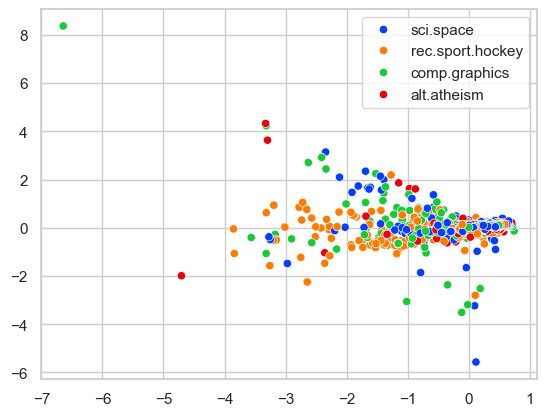

In [88]:
# AVG vec over doc, i.e. per cat
def get_doc_vector(doc, model):
    vectors = [model.wv[word] for word in doc if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

X_vectors = np.array([get_doc_vector(doc, model) for doc in X_text])

pca = PCA(n_components=2)
coords = pca.fit_transform(X_vectors)

sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=y_mapped, palette="bright")

<Axes: >

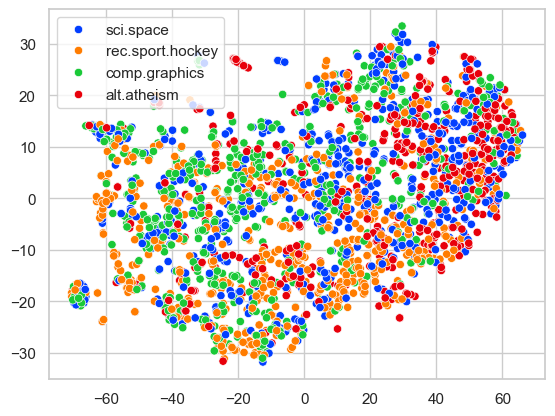

In [84]:
tsne = TSNE(n_components=2)
coords = tsne.fit_transform(X_vectors)

sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=y_mapped, palette="bright")

In [85]:
# Recycling code from EX 1
representative_words: list[tuple[str, str]] = []
categories = []
feature_names = tv.get_feature_names_out()
for cat_id, cat in enumerate(target_names):
    mask: ndarray = (y == cat_id)
    avg_tfidf: ndarray = tfidf_rep[mask].mean(axis=0).A1 # type:ignore
    top = feature_names[avg_tfidf.argsort()[-5:][::-1]]
    representative_words.extend(top)
    categories.extend([cat for _ in range(5)])
    print(f"Top terms for {cat}: {top}")

Top terms for alt.atheism: ['god' 'people' 'don' 'think' 'just']
Top terms for comp.graphics: ['graphics' 'thanks' 'image' 'files' 'file']
Top terms for rec.sport.hockey: ['game' 'team' 'hockey' 'games' 'play']
Top terms for sci.space: ['space' 'nasa' 'like' 'launch' 'moon']


*AI USAGE*

Prompt:

"i have maptlotlib and seaboarn. i want a scatter with 20 points with 2d coords the points should either be the lable themselves or be labled from the list of tuples containing strings and their category i have in the same order as the coords and the categories should be used to color it"

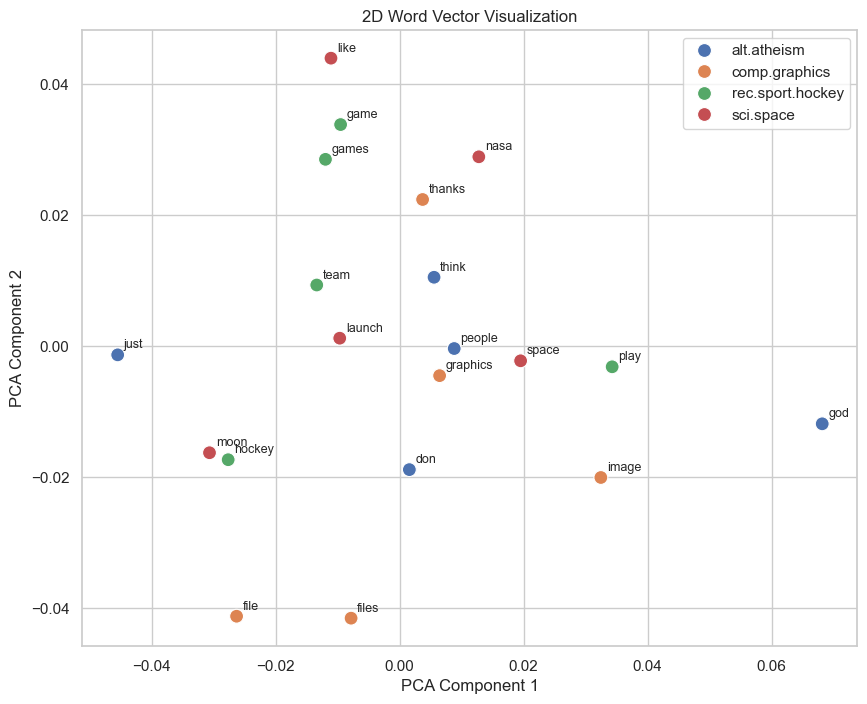

In [ ]:
wv = []
for word in representative_words:
    wv.append(model.wv[word])

pca = PCA(n_components=2)
coords = pca.fit_transform(wv)

# 2. Setup Plot
plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# 3. Create Scatter (to handle the color legend)
ax = sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=categories, s=100)

# 4. Annotate each point with its Word
for i, word in enumerate(representative_words):
    ax.text(coords[i, 0] + 0.001, coords[i, 1] + 0.001, word, fontsize=9)

plt.title("2D Word Vector Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

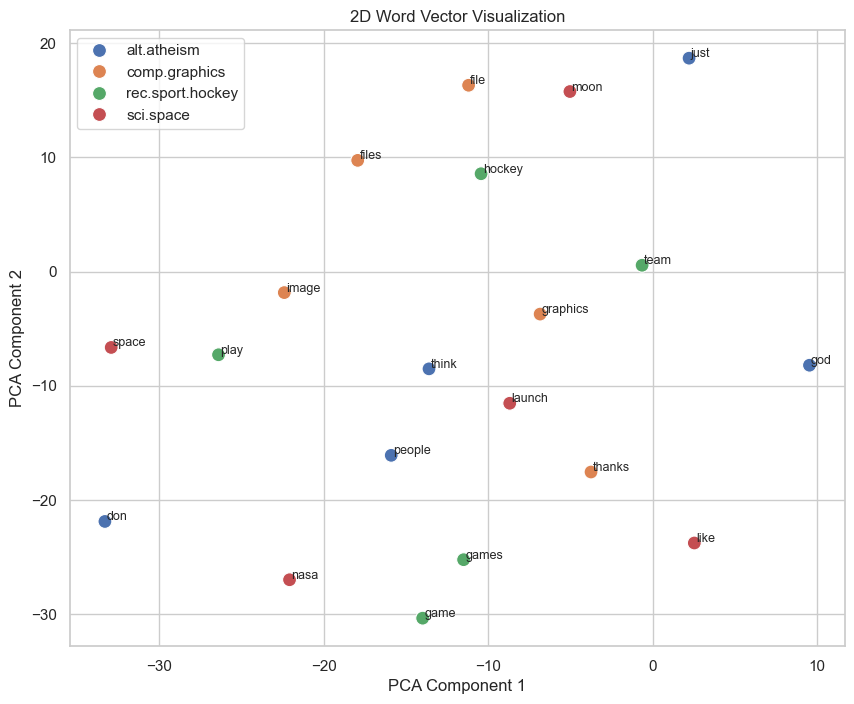

In [87]:
tsne = TSNE(n_components=2, perplexity=7)
coords = tsne.fit_transform(np.array(wv))

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# 3. Create Scatter (to handle the color legend)
ax = sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=categories, s=100)

# 4. Annotate each point with its Word
for i, word in enumerate(representative_words):
    ax.text(coords[i, 0] + 0.1, coords[i, 1] + 0.1, word, fontsize=9)

plt.title("2D Word Vector Visualization")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()